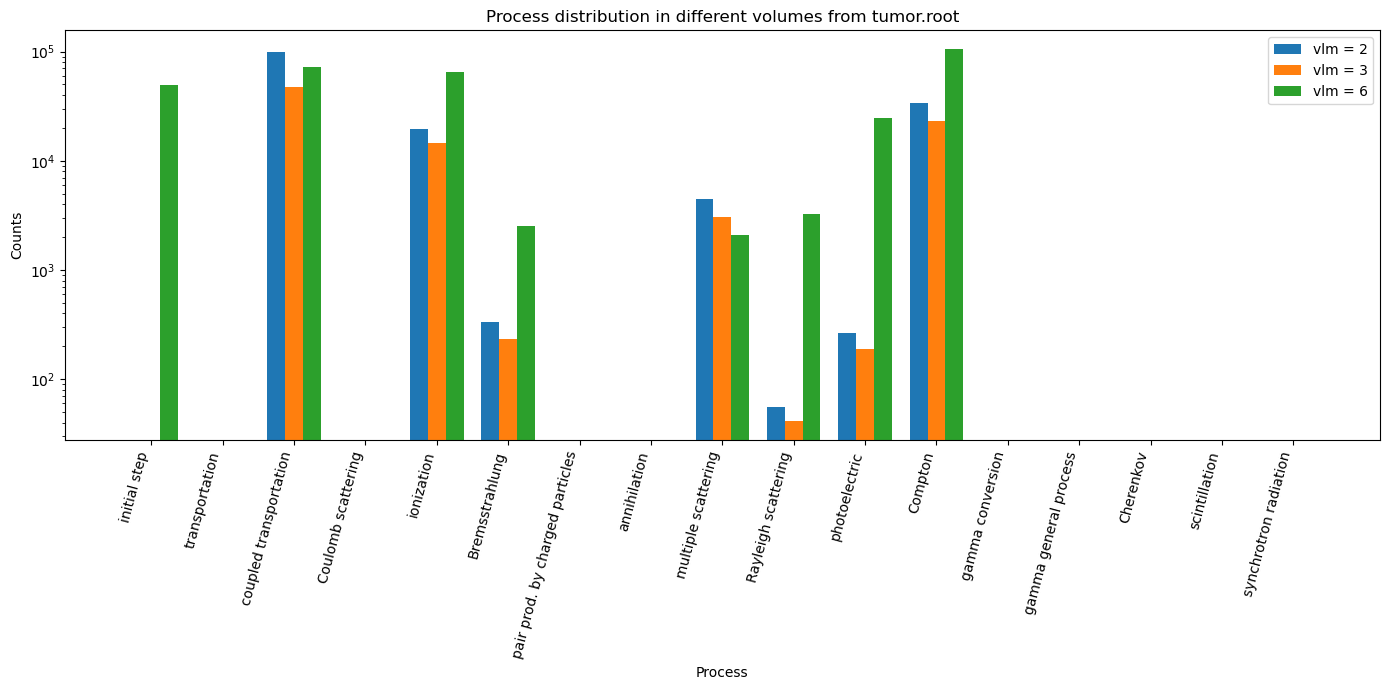

In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

# ROOT file
file_path = "tumor.root"

# Volumes you want to compare
selected_vlms = [2, 3, 6]

# Process IDs you want to plot
process_dict = {
    1000: "initial step",
    1091: "transportation",
    1092: "coupled transportation",
    2001: "Coulomb scattering",
    2002: "ionization",
    2003: "Bremsstrahlung",
    2004: "pair prod. by charged particles",
    2005: "annihilation",
    2010: "multiple scattering",
    2011: "Rayleigh scattering",
    2012: "photoelectric",
    2013: "Compton",
    2014: "gamma conversion",
    2016: "gamma general process",
    2021: "Cherenkov",
    2022: "scintillation",
    2023: "synchrotron radiation"
}

process_ids = list(process_dict.keys())

# Read ROOT file
with uproot.open(file_path) as f:
    tree = f["t"]

    pro_raw = tree["pro"].array(library="np")
    vlm_raw = tree["vlm"].array(library="np")

    # Flatten arrays
    pro = np.concatenate(pro_raw).ravel()
    vlm = np.concatenate(vlm_raw).ravel()

# Count process occurrences in each selected volume
counts = {v: [] for v in selected_vlms}

for v in selected_vlms:
    mask_v = (vlm == v)
    pro_v = pro[mask_v]

    for pid in process_ids:
        counts[v].append(np.count_nonzero(pro_v == pid))

# Plot
x = np.arange(len(process_ids))
width = 0.25

plt.figure(figsize=(14, 7))
for i, v in enumerate(selected_vlms):
    plt.bar(x + i * width, counts[v], width=width, label=f"vlm = {v}")

plt.xticks(x + width, [process_dict[pid] for pid in process_ids], rotation=75, ha='right')
plt.yscale("log")   # optional, useful if counts vary a lot
plt.ylabel("Counts")
plt.xlabel("Process")
plt.title("Process distribution in different volumes from tumor.root")
plt.legend()
plt.tight_layout()
plt.show()